# Predicción del MOID Orbital en NEOs
## Regresión, Clasificación y Prueba Histórica Retrospectiva

Este notebook consolida el análisis completo de Machine Learning para predecir el **MOID**
(Minimum Orbit Intersection Distance) de NEOs, incluyendo:

1. **Regresión continua del MOID**: estimar el valor exacto en AU
2. **Clasificación binaria de peligrosidad**: detectar MOID ≤ 0.05 au
3. **Validación física y restricción geométrica**: coherencia orbital
4. **Holdout temporal**: entrenado ≤2014, evaluado ≥2015
5. **🔭 Prueba Histórica Retrospectiva**: se entrena SIN ver el MOID de NEOs antiguos (pre-2000)
   y se evalúa si las predicciones coinciden con el MOID real ya conocido.

**Dataset:** `close_approaches.csv` (NASA JPL)  
**Umbral oficial:** MOID ≤ 0.05 au  |  **Semilla:** 42

## 0. Importaciones y configuración

In [1]:
import glob, json, os, sys, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import (
    GradientBoostingClassifier, GradientBoostingRegressor,
    RandomForestClassifier, RandomForestRegressor,
)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    fbeta_score, mean_absolute_error, mean_squared_error,
    precision_recall_curve, precision_score, r2_score,
    recall_score, roc_auc_score, roc_curve, confusion_matrix,
)
from sklearn.model_selection import KFold, StratifiedKFold

try:
    import xgboost as xgb
    HAS_XGB = True
    print(f'XGBoost {xgb.__version__} disponible')
except ImportError:
    HAS_XGB = False
    print('XGBoost no disponible — se usará GradientBoosting de sklearn')

SEED          = 42
UMBRAL_MOID   = 0.05
THRESHOLD_PROB = 0.35

AZUL    = '#2b5c8f'
VERDE   = '#2e8b57'
NARANJA = '#e67e22'
ROJO    = '#c0392b'
VIOLETA = '#8e44ad'
GRIS    = '#7f8c8d'

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
    'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.5, 'font.size': 11,
})
print('Entorno listo')


XGBoost 3.4.1 disponible
Entorno listo


## 1. Carga y preparación de datos

In [2]:
BASE_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
DIR_DATA = os.path.join(BASE_DIR, 'data')
DIR_FIG  = os.path.join(BASE_DIR, 'results', 'figures')
DIR_TAB  = os.path.join(BASE_DIR, 'results', 'tables')
os.makedirs(DIR_FIG, exist_ok=True)
os.makedirs(DIR_TAB, exist_ok=True)

ruta_std = os.path.join(DIR_DATA, 'close_approaches.csv')
snaps    = sorted(glob.glob(os.path.join(DIR_DATA, 'close_approaches_v*.csv')))
ruta_csv = ruta_std if os.path.exists(ruta_std) else (snaps[-1] if snaps else None)
if ruta_csv is None:
    raise FileNotFoundError('No se encontró close_approaches.csv en data/')

print(f'Cargando: {os.path.basename(ruta_csv)}')
df_raw = pd.read_csv(ruta_csv)
print(f'Filas: {len(df_raw):,} | Columnas: {df_raw.shape[1]}')
df_raw.head(3)


Cargando: close_approaches.csv
Filas: 340,469 | Columnas: 17


,Object,Close-Approach (CA) Date,CA DistanceNominal (au),CA DistanceMinimum (au),V relative(km/s),V infinity(km/s),H(mag),Diameter(km),Std Diameter(km),MOID (au),H_SBDB(mag),first_obs_year,data_arc(d),n_obs_used,PHA_official,post_discovery,PHA_proxy
0,170903,1900-Jan-01 00:38,0.092616,0.092465,16.739173,16.737455,18.2,0.813694,0.284793,0.0300,18.2,2002.0,8415.0,1566,1.0,0,0
1,2006 XO4,1900-Jan-01 03:13,0.114291,0.114273,7.397204,7.394052,23.4,0.074210,0.025973,0.0271,23.4,2006.0,3666.0,60,0.0,0,0
2,2014 YT34,1900-Jan-01 11:48,0.265302,0.263136,12.974238,12.973464,24.7,0.040781,0.014273,0.0359,24.7,2014.0,171.0,72,0.0,0,0


In [3]:
def cargar_y_agregar(df_raw):
    obs = df_raw[df_raw['post_discovery'] == 1].copy()
    obs['dist_unc'] = obs['CA DistanceNominal (au)'] - obs['CA DistanceMinimum (au)']
    obj = obs.groupby('Object').agg(
        distnom_min   = ('CA DistanceNominal (au)', 'min'),
        distmin_min   = ('CA DistanceMinimum (au)', 'min'),
        vinf_max      = ('V infinity(km/s)', 'max'),
        vinf_med      = ('V infinity(km/s)', 'median'),
        H_obs         = ('H(mag)', 'min'),
        n_appro       = ('Object', 'size'),
        dist_unc_med  = ('dist_unc', 'median'),
        moid          = ('MOID (au)', 'max'),
        pha           = ('PHA_official', 'max'),
        first_obs_year= ('first_obs_year', 'max'),
    ).reset_index()
    obj = obj.dropna(subset=['moid', 'distnom_min', 'vinf_max', 'H_obs']).copy()
    obj['is_moid_hazardous']  = (obj['moid'] <= UMBRAL_MOID).astype(int)
    obj['is_proxy_hazardous'] = (obj['distnom_min'] <= UMBRAL_MOID).astype(int)
    n = len(obj)
    ph = obj['is_moid_hazardous'].sum()
    print(f'Objetos: {n:,} | PHAs reales: {ph:,} ({100*ph/n:.1f}%)')
    print(f'Rango first_obs_year: {obj["first_obs_year"].min():.0f} - {obj["first_obs_year"].max():.0f}')
    return obj

obj = cargar_y_agregar(df_raw)
obj.describe()


Objetos: 37,405 | PHAs reales: 22,233 (59.4%)
Rango first_obs_year: 1893 - 2026


,distnom_min,distmin_min,vinf_max,vinf_med,H_obs,n_appro,dist_unc_med,moid,pha,first_obs_year,is_moid_hazardous,is_proxy_hazardous
count,37405.000000,37405.000000,37405.000000,37405.000000,37405.000000,37405.000000,3.740500e+04,3.740500e+04,37405.000000,37405.000000,37405.000000,37405.000000
mean,0.090622,0.089620,13.281739,11.721415,24.156080,1.988183,4.109007e-03,6.496753e-02,0.060500,2016.911777,0.594386,0.466863
std,0.095201,0.094490,6.953355,6.055881,2.628478,1.987023,1.294953e-02,7.693627e-02,0.238414,7.967616,0.491017,0.498907
min,0.000044,0.000000,0.030846,0.030846,10.400000,1.000000,2.561989e-10,4.700000e-07,0.000000,1893.000000,0.000000,0.000000
25%,0.020386,0.020060,7.950913,7.287418,22.400000,1.000000,5.594751e-06,9.810000e-03,0.000000,2013.000000,0.000000,0.000000
50%,0.056283,0.055390,12.045411,10.571342,24.400000,1.000000,1.257679e-04,3.390000e-02,0.000000,2019.000000,1.000000,0.000000
75%,0.131162,0.129446,17.411488,14.916700,26.000000,2.000000,1.150748e-03,9.310000e-02,0.000000,2023.000000,1.000000,1.000000
max,0.499998,0.499964,65.830229,65.830229,34.060000,46.000000,2.849453e-01,4.950000e-01,1.000000,2026.000000,1.000000,1.000000


## 2. Regresión continua del MOID

**Features:** `distnom_min`, `vinf_max`, `H_obs`, `n_appro`, `dist_unc_med`  
**Validación:** K-Fold 5 pliegues (Out-of-Fold)  
**Baseline ingenuo:** usar `distnom_min` directamente como predicción del MOID

In [4]:
FEATURES = ['distnom_min', 'vinf_max', 'H_obs', 'n_appro', 'dist_unc_med']
X = obj[FEATURES].values
y = obj['moid'].values
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

r2_naive  = r2_score(y, obj['distnom_min'].values)
mae_naive = mean_absolute_error(y, obj['distnom_min'].values)
print(f'Baseline ingenuo: R2={r2_naive:.4f} | MAE={mae_naive:.4f} au')

if HAS_XGB:
    modelo_gb = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                                  subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=-1)
    gb_name = 'XGBoost'
else:
    modelo_gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=SEED)
    gb_name = 'GradientBoosting'

modelos_reg = {
    'Ridge'         : Ridge(alpha=1.0),
    'Random Forest' : RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
    gb_name         : modelo_gb,
}
resultados_reg = {}
preds_oof_reg  = {}

for nombre, model in modelos_reg.items():
    r2l, mael, rmsel, oof = [], [], [], np.zeros(len(y))
    for tr, va in kf.split(X):
        model.fit(X[tr], y[tr])
        p = model.predict(X[va])
        oof[va] = p
        r2l.append(r2_score(y[va], p))
        mael.append(mean_absolute_error(y[va], p))
        rmsel.append(np.sqrt(mean_squared_error(y[va], p)))
    resultados_reg[nombre] = {'R2': float(np.mean(r2l)), 'MAE': float(np.mean(mael)), 'RMSE': float(np.mean(rmsel))}
    preds_oof_reg[nombre] = oof
    print(f'  {nombre:<20}: R2={np.mean(r2l):.4f}±{np.std(r2l):.4f} | MAE={np.mean(mael):.4f} au')


Baseline ingenuo: R2=0.5080 | MAE=0.0259 au
  Ridge               : R2=0.7715±0.0071 | MAE=0.0227 au
  Random Forest       : R2=0.7966±0.0036 | MAE=0.0195 au
  XGBoost             : R2=0.8057±0.0051 | MAE=0.0194 au


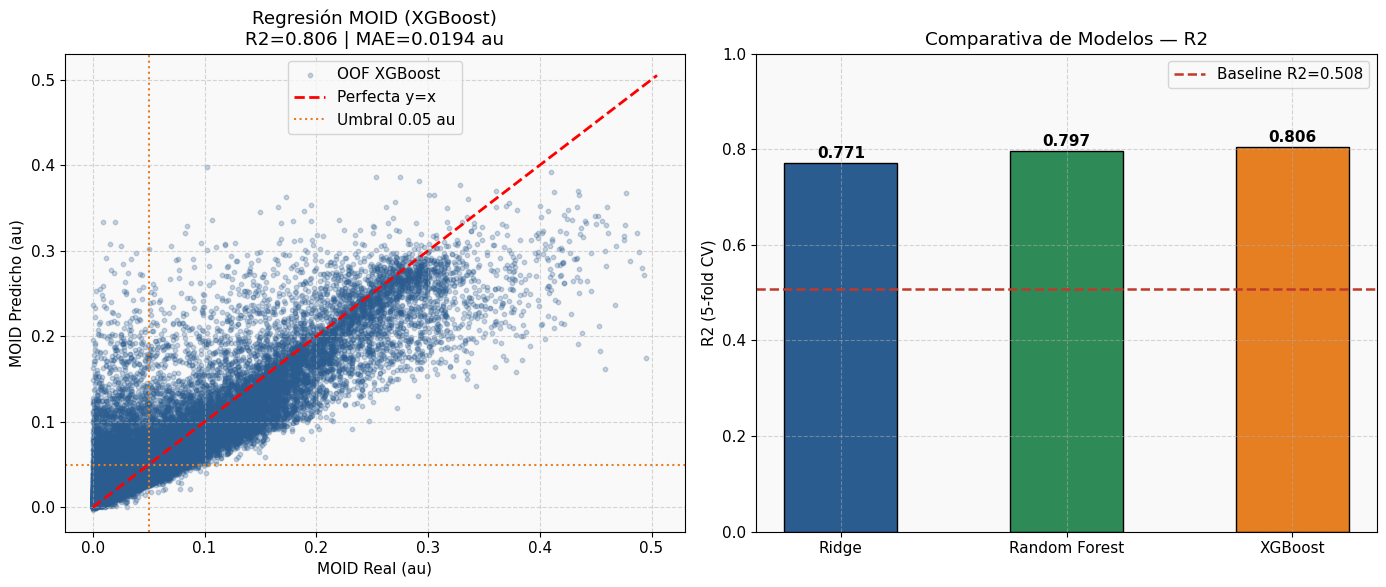

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(y, preds_oof_reg[gb_name], alpha=0.25, s=10, color=AZUL, label=f'OOF {gb_name}')
lim = y.max() * 1.02
ax.plot([0, lim], [0, lim], 'r--', lw=2, label='Perfecta y=x')
ax.axvline(UMBRAL_MOID, color=NARANJA, ls=':', lw=1.5, label='Umbral 0.05 au')
ax.axhline(UMBRAL_MOID, color=NARANJA, ls=':', lw=1.5)
ax.set_xlabel('MOID Real (au)'); ax.set_ylabel('MOID Predicho (au)')
ax.set_title(f'Regresión MOID ({gb_name})\nR2={resultados_reg[gb_name]["R2"]:.3f} | MAE={resultados_reg[gb_name]["MAE"]:.4f} au')
ax.legend()

ax2 = axes[1]
names = list(resultados_reg.keys())
r2v   = [resultados_reg[n]['R2'] for n in names]
xp    = np.arange(len(names))
bars  = ax2.bar(xp, r2v, color=[AZUL, VERDE, NARANJA], edgecolor='black', width=0.5)
ax2.axhline(r2_naive, color=ROJO, ls='--', lw=1.8, label=f'Baseline R2={r2_naive:.3f}')
ax2.set_xticks(xp); ax2.set_xticklabels(names); ax2.set_ylim(0, 1)
ax2.set_ylabel('R2 (5-fold CV)'); ax2.set_title('Comparativa de Modelos — R2'); ax2.legend()
for bar, val in zip(bars, r2v):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DIR_FIG, 'regression_moid_comparison.png'), dpi=200)
plt.show()


## 3. Clasificación binaria — MOID ≤ 0.05 au

Se usa **F2-score** como métrica principal (penaliza más los falsos negativos,
crítico en defensa planetaria).

In [6]:
y_cls = obj['is_moid_hazardous'].values
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

prec_proxy = precision_score(y_cls, obj['is_proxy_hazardous'].values, zero_division=0)
rec_proxy  = recall_score(y_cls, obj['is_proxy_hazardous'].values)
f2_proxy   = fbeta_score(y_cls, obj['is_proxy_hazardous'].values, beta=2)
print(f'Proxy (distnom_min<=0.05): Prec={prec_proxy:.4f} | Recall={rec_proxy:.4f} | F2={f2_proxy:.4f}')

if HAS_XGB:
    spw = (len(y_cls)-y_cls.sum())/y_cls.sum()
    modelo_cls_gb = xgb.XGBClassifier(n_estimators=200, scale_pos_weight=spw, learning_rate=0.05,
                                       max_depth=5, subsample=0.8, random_state=SEED, n_jobs=-1)
    gb_cls_name = 'XGBoost'
else:
    modelo_cls_gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=SEED)
    gb_cls_name = 'GradientBoosting'

modelos_cls = {
    'Reg. Logistica': LogisticRegression(class_weight='balanced', random_state=SEED, max_iter=1000),
    'Random Forest' : RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1),
    gb_cls_name     : modelo_cls_gb,
}
resultados_cls = {}
probs_oof_cls  = {}

for nombre, model in modelos_cls.items():
    f2l, precl, recl, rocl = [], [], [], []
    oof = np.zeros(len(y_cls))
    for tr, va in skf.split(X, y_cls):
        model.fit(X[tr], y_cls[tr])
        pr = model.predict_proba(X[va])[:, 1]
        oof[va] = pr
        pd_ = (pr >= THRESHOLD_PROB).astype(int)
        f2l.append(fbeta_score(y_cls[va], pd_, beta=2))
        precl.append(precision_score(y_cls[va], pd_, zero_division=0))
        recl.append(recall_score(y_cls[va], pd_))
        rocl.append(roc_auc_score(y_cls[va], pr))
    resultados_cls[nombre] = {'F2': float(np.mean(f2l)), 'Precision': float(np.mean(precl)),
                              'Recall': float(np.mean(recl)), 'ROC_AUC': float(np.mean(rocl))}
    probs_oof_cls[nombre] = oof
    print(f'  {nombre:<20}: F2={np.mean(f2l):.4f} | Prec={np.mean(precl):.4f} | Recall={np.mean(recl):.4f} | AUC={np.mean(rocl):.4f}')


Proxy (distnom_min<=0.05): Prec=0.9990 | Recall=0.7846 | F2=0.8198
  Reg. Logistica      : F2=0.9075 | Prec=0.8291 | Recall=0.9294 | AUC=0.9458
  Random Forest       : F2=0.9105 | Prec=0.8850 | Recall=0.9171 | AUC=0.9604
  XGBoost             : F2=0.8978 | Prec=0.9361 | Recall=0.8887 | AUC=0.9632


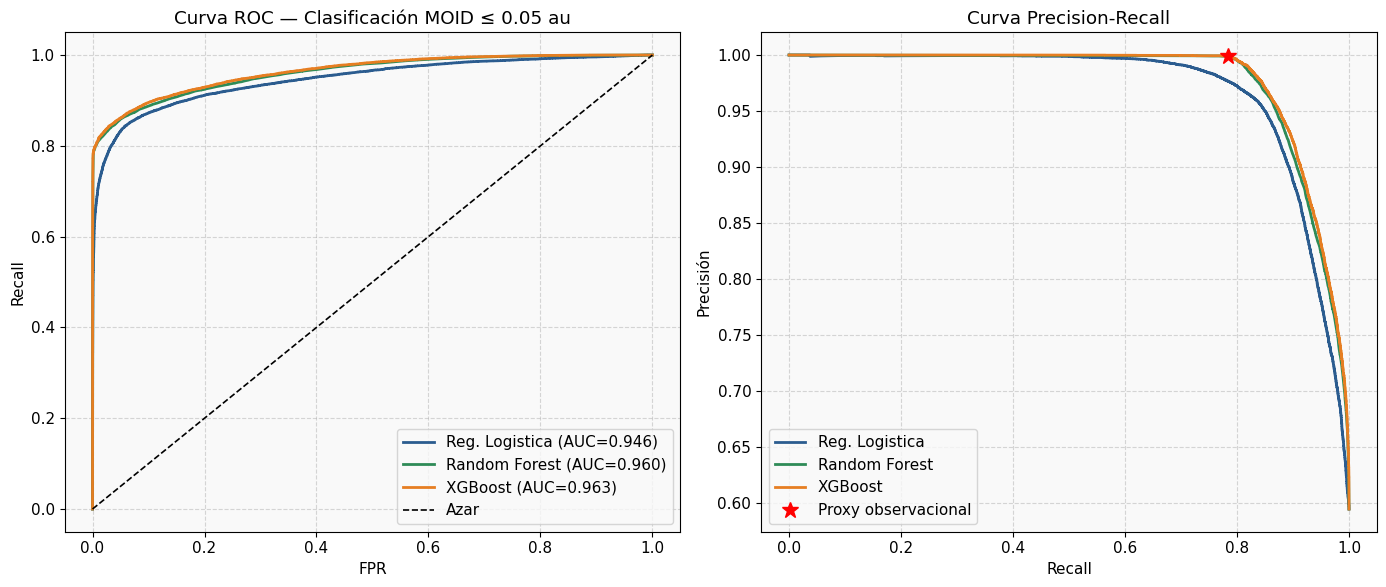

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colores_m = [AZUL, VERDE, NARANJA]
for (nombre, probs), color in zip(probs_oof_cls.items(), colores_m):
    auc = resultados_cls[nombre]['ROC_AUC']
    fpr, tpr, _ = roc_curve(y_cls, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC={auc:.3f})')
    prec_c, rec_c, _ = precision_recall_curve(y_cls, probs)
    axes[1].plot(rec_c, prec_c, color=color, lw=2, label=nombre)
axes[0].plot([0,1],[0,1],'k--',lw=1.2,label='Azar')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('Recall'); axes[0].legend()
axes[0].set_title('Curva ROC — Clasificación MOID ≤ 0.05 au')
axes[1].plot(rec_proxy, prec_proxy, 'r*', ms=12, label='Proxy observacional')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precisión'); axes[1].legend()
axes[1].set_title('Curva Precision-Recall')
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIG, 'moid_classification_roc_pr.png'), dpi=200)
plt.show()


## 4. Validación física — Restricción Geométrica del MOID

**Principio:** El MOID siempre debe ser ≤ `distnom_min`.
Predicciones que violen esto son físicamente imposibles.

In [8]:
oof_libre   = preds_oof_reg[gb_name].copy()
distnom_arr = obj['distnom_min'].values
viol_mask   = oof_libre > distnom_arr
n_viol      = viol_mask.sum()
pct_viol    = n_viol / len(y) * 100
print(f'Violaciones geométricas: {n_viol:,} ({pct_viol:.2f}%)')

oof_rest  = np.minimum(oof_libre, distnom_arr)
r2_libre  = r2_score(y, oof_libre)
mae_libre = mean_absolute_error(y, oof_libre)
r2_rest   = r2_score(y, oof_rest)
mae_rest  = mean_absolute_error(y, oof_rest)
mejora    = (mae_libre - mae_rest) / mae_libre * 100
print(f'Libre       : R2={r2_libre:.4f} | MAE={mae_libre:.4f} au')
print(f'Restringido : R2={r2_rest:.4f} | MAE={mae_rest:.4f} au')
print(f'Mejora MAE al forzar física: {mejora:.2f}%')


Violaciones geométricas: 1,787 (4.78%)
Libre       : R2=0.8057 | MAE=0.0194 au
Restringido : R2=0.8058 | MAE=0.0193 au
Mejora MAE al forzar física: 0.38%


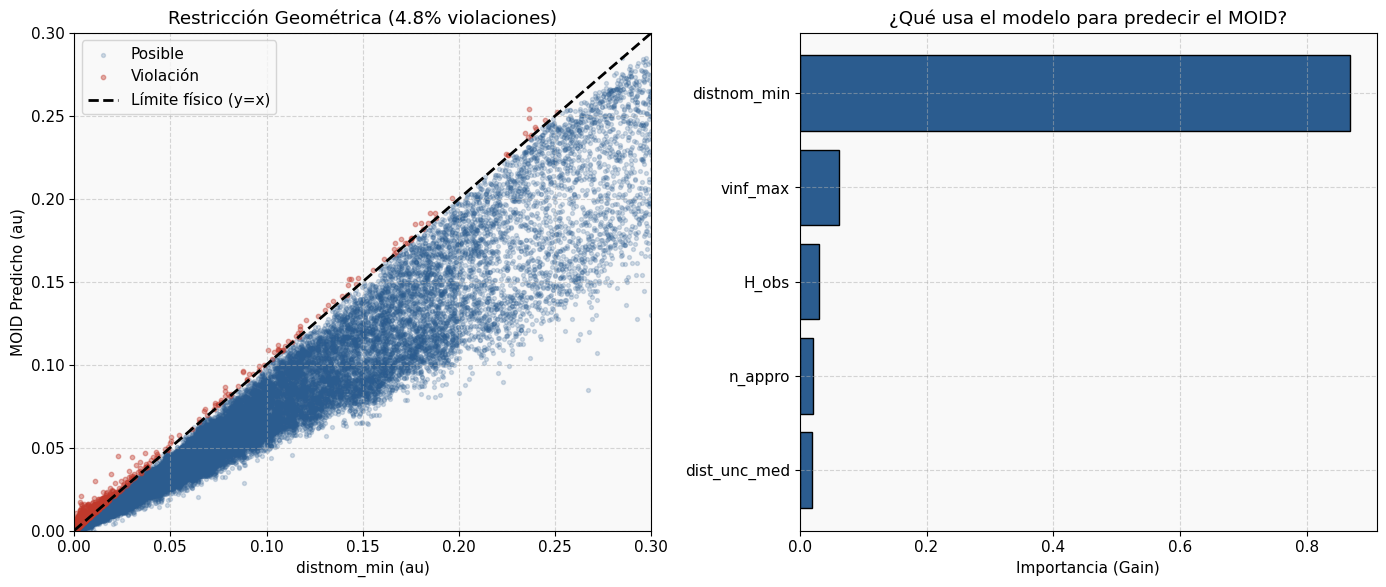

In [9]:
modelo_full = (xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=SEED, n_jobs=-1)
               if HAS_XGB else
               GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=SEED))
modelo_full.fit(X, y)
importances = modelo_full.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
ax.scatter(distnom_arr[~viol_mask], oof_libre[~viol_mask], alpha=0.2, s=8, color=AZUL, label='Posible')
ax.scatter(distnom_arr[viol_mask],  oof_libre[viol_mask],  alpha=0.4, s=10, color=ROJO, label='Violación')
mv = min(0.3, max(distnom_arr.max(), oof_libre.max()))
ax.plot([0,mv],[0,mv],'k--',lw=2,label='Límite físico (y=x)')
ax.set_xlim(0,mv); ax.set_ylim(0,mv)
ax.set_xlabel('distnom_min (au)'); ax.set_ylabel('MOID Predicho (au)')
ax.set_title(f'Restricción Geométrica ({pct_viol:.1f}% violaciones)'); ax.legend()

ax2 = axes[1]
idx = np.argsort(importances)
ax2.barh(range(len(idx)), importances[idx], color=AZUL, edgecolor='black')
ax2.set_yticks(range(len(idx))); ax2.set_yticklabels([FEATURES[i] for i in idx])
ax2.set_xlabel('Importancia (Gain)'); ax2.set_title('¿Qué usa el modelo para predecir el MOID?')
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIG, 'moid_physics_validation.png'), dpi=200)
plt.show()


## 5. Holdout Temporal (Entrenado ≤2014, Evaluado ≥2015)

In [10]:
df_tr = obj[obj['first_obs_year'] <= 2014].copy()
df_te = obj[obj['first_obs_year'] >= 2015].copy()
print(f'Entrenamiento (<=2014): {len(df_tr):,} | Evaluación (>=2015): {len(df_te):,}')

X_tr = df_tr[FEATURES].values; y_tr_r = df_tr['moid'].values; y_tr_c = df_tr['is_moid_hazardous'].values
X_te = df_te[FEATURES].values; y_te_r = df_te['moid'].values; y_te_c = df_te['is_moid_hazardous'].values

reg_t = (xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=SEED, n_jobs=-1)
         if HAS_XGB else GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=SEED))
reg_t.fit(X_tr, y_tr_r)
p_r = reg_t.predict(X_te)
print(f'Regresión Temporal: R2={r2_score(y_te_r, p_r):.4f} | MAE={mean_absolute_error(y_te_r, p_r):.4f} au')

spw_t = (len(y_tr_c)-y_tr_c.sum())/y_tr_c.sum()
cls_t = (xgb.XGBClassifier(n_estimators=200, scale_pos_weight=spw_t, learning_rate=0.05,
                            max_depth=5, random_state=SEED, n_jobs=-1)
         if HAS_XGB else GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=SEED))
cls_t.fit(X_tr, y_tr_c)
p_c = (cls_t.predict_proba(X_te)[:, 1] >= THRESHOLD_PROB).astype(int)
print(f'Clasificación Temporal: F2={fbeta_score(y_te_c, p_c, beta=2):.4f} | '
      f'Prec={precision_score(y_te_c, p_c, zero_division=0):.4f} | '
      f'Recall={recall_score(y_te_c, p_c):.4f}')


Entrenamiento (<=2014): 10,880 | Evaluación (>=2015): 26,525
Regresión Temporal: R2=0.8048 | MAE=0.0168 au
Clasificación Temporal: F2=0.9111 | Prec=0.9423 | Recall=0.9036


## 6. Prueba Histórica Retrospectiva

### Concepto de la prueba

Los **NEOs más antiguos** (descubiertos antes del 2000) tienen un MOID muy bien determinado
por los astrónomos a lo largo de décadas.

**Protocolo:**
1. NEOs históricos (pre-2000) → conjunto de **PRUEBA**
2. Entrenar con NEOs modernos (2000+) → **SIN ver el MOID histórico**
3. Predecir el MOID de los NEOs históricos solo con sus features observacionales
4. Comparar predicción vs MOID real conocido

> Si las predicciones se acercan al MOID real → el modelo aprendió relaciones físico-cinemáticas
> genuinas, no solo memorización.

In [21]:
ANIO_CORTE    = 2000
df_historicos = obj[obj['first_obs_year'] < ANIO_CORTE].copy()
df_modernos   = obj[obj['first_obs_year'] >= ANIO_CORTE].copy()

print('=' * 65)
print('PRUEBA HISTÓRICA RETROSPECTIVA')
print('=' * 65)
n_h  = len(df_historicos)
ph_h = df_historicos['is_moid_hazardous'].sum()
n_m  = len(df_modernos)
ph_m = df_modernos['is_moid_hazardous'].sum()
print(f'NEOs históricos (pre-2000) — PRUEBA      : {n_h:,}')
print(f'  PHAs reales: {ph_h:,} ({100*ph_h/n_h:.1f}%)')
print(f'  Rango años : {df_historicos["first_obs_year"].min():.0f} - {df_historicos["first_obs_year"].max():.0f}')
print(f'  n_appro media: {df_historicos["n_appro"].mean():.1f}')
print(f'NEOs modernos  (2000+)     — ENTRENAMIENTO: {n_m:,}')
print(f'  PHAs reales: {ph_m:,} ({100*ph_m/n_m:.1f}%)')


PRUEBA HISTÓRICA RETROSPECTIVA
NEOs históricos (pre-2000) — PRUEBA      : 906
  PHAs reales: 381 (42.1%)
  Rango años : 1893 - 1999
  n_appro media: 3.6
NEOs modernos  (2000+)     — ENTRENAMIENTO: 36,499
  PHAs reales: 21,852 (59.9%)


In [22]:
# Entrenar regresor con datos MODERNOS (sin ver el MOID histórico)
X_mod = df_modernos[FEATURES].values
y_mod = df_modernos['moid'].values

reg_hist = (xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                              subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=-1)
            if HAS_XGB else
            GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=SEED))
reg_hist.fit(X_mod, y_mod)

rf_hist    = RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1)
rf_hist.fit(X_mod, y_mod)

ridge_hist = Ridge(alpha=1.0)
ridge_hist.fit(X_mod, y_mod)

print(f' Modelos entrenados con {len(df_modernos):,} NEOs modernos')
print(f'   El MOID de los {len(df_historicos):,} NEOs históricos NO fue visto en el entrenamiento.')


 Modelos entrenados con 36,499 NEOs modernos
   El MOID de los 906 NEOs históricos NO fue visto en el entrenamiento.


In [23]:
# Predecir MOID histórico sin haberlo visto
X_hist = df_historicos[FEATURES].values
y_hist = df_historicos['moid'].values

pred_gb    = reg_hist.predict(X_hist)
pred_rf    = rf_hist.predict(X_hist)
pred_ridge = ridge_hist.predict(X_hist)
pred_ens   = (pred_gb + pred_rf + pred_ridge) / 3

distnom_h  = df_historicos['distnom_min'].values
pred_gb_r  = np.minimum(pred_gb,  distnom_h)
pred_ens_r = np.minimum(pred_ens, distnom_h)

modelos_h = {
    gb_name                   : pred_gb,
    'Random Forest'           : pred_rf,
    'Ridge'                   : pred_ridge,
    'Ensemble'                : pred_ens,
    f'{gb_name}+restricción'  : pred_gb_r,
    'Ensemble+restricción'    : pred_ens_r,
}

print(f'{"Modelo":<30} {"R2":>8} {"MAE (au)":>10} {"RMSE (au)":>11}')
print('-' * 65)
metricas_h = {}
for nombre, preds in modelos_h.items():
    r2_h   = r2_score(y_hist, preds)
    mae_h  = mean_absolute_error(y_hist, preds)
    rmse_h = np.sqrt(mean_squared_error(y_hist, preds))
    metricas_h[nombre] = {'R2': r2_h, 'MAE': mae_h, 'RMSE': rmse_h}
    print(f'  {nombre:<28} {r2_h:>8.4f} {mae_h:>10.4f} {rmse_h:>11.4f}')
r2_base  = r2_score(y_hist, distnom_h)
mae_base = mean_absolute_error(y_hist, distnom_h)
print('-' * 65)
print(f'  {"Baseline (distnom_min)":<28} {r2_base:>8.4f} {mae_base:>10.4f}')


Modelo                               R2   MAE (au)   RMSE (au)
-----------------------------------------------------------------
  XGBoost                        0.7620     0.0270      0.0391
  Random Forest                  0.7363     0.0284      0.0412
  Ridge                          0.7449     0.0294      0.0405
  Ensemble                       0.7638     0.0273      0.0390
  XGBoost+restricción            0.7629     0.0268      0.0390
  Ensemble+restricción           0.7639     0.0273      0.0390
-----------------------------------------------------------------
  Baseline (distnom_min)         0.5766     0.0298


In [24]:
# Clasificación histórica — ¿detecta PHAs antiguos?
y_mod_cls = df_modernos['is_moid_hazardous'].values
spw2      = (len(y_mod_cls) - y_mod_cls.sum()) / max(y_mod_cls.sum(), 1)
cls_hist  = (xgb.XGBClassifier(n_estimators=300, scale_pos_weight=spw2, learning_rate=0.05,
                               max_depth=6, random_state=SEED, n_jobs=-1)
            if HAS_XGB else
            GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=SEED))
cls_hist.fit(df_modernos[FEATURES].values, y_mod_cls)
probs_h     = cls_hist.predict_proba(X_hist)[:, 1]
preds_cls_h = (probs_h >= THRESHOLD_PROB).astype(int)
y_hist_cls  = df_historicos['is_moid_hazardous'].values

f2_h   = fbeta_score(y_hist_cls, preds_cls_h, beta=2)
prec_h = precision_score(y_hist_cls, preds_cls_h, zero_division=0)
rec_h  = recall_score(y_hist_cls, preds_cls_h)
print(f'Clasificación PHAs históricos: F2={f2_h:.4f} | Prec={prec_h:.4f} | Recall={rec_h:.4f}')
n_phas_real = int(y_hist_cls.sum())
n_phas_det  = int(preds_cls_h[y_hist_cls==1].sum())
print(f'Detectados: {n_phas_det} de {n_phas_real} PHAs históricos reales ({100*n_phas_det/max(n_phas_real,1):.1f}%)')


Clasificación PHAs históricos: F2=0.7884 | Prec=0.8142 | Recall=0.7822
Detectados: 298 de 381 PHAs históricos reales (78.2%)


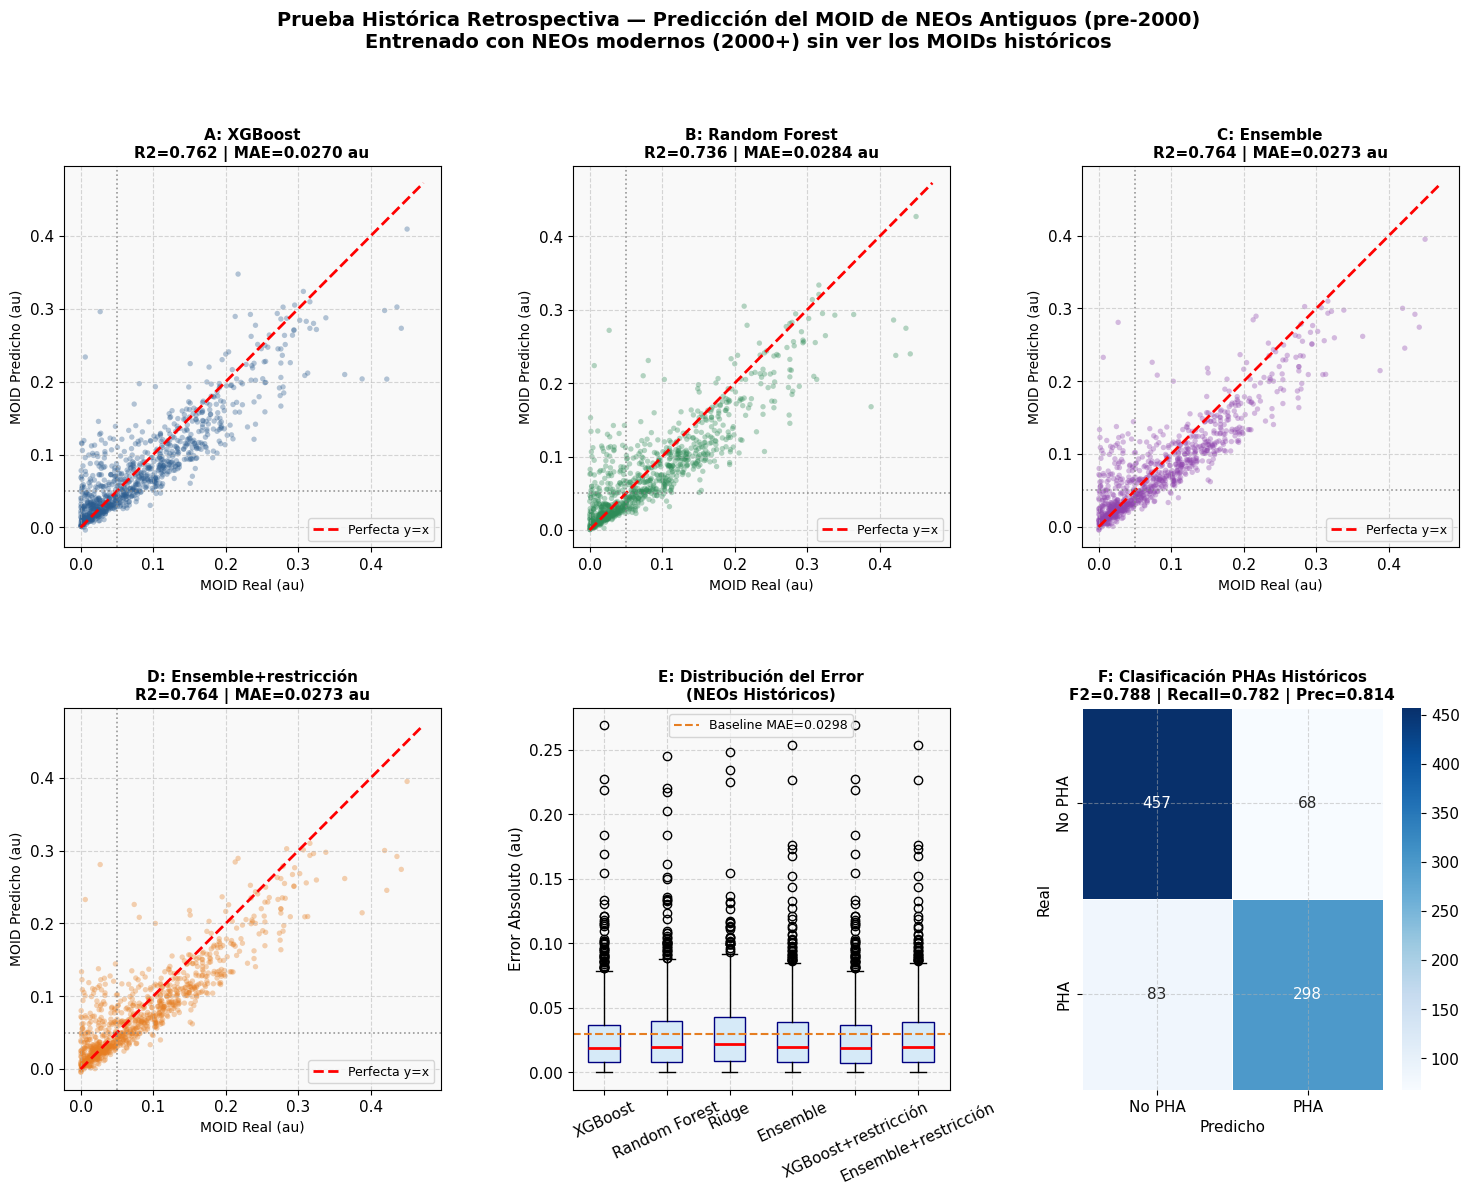

Figura guardada: results/figures/historical_retroactive_test.png


In [25]:
# Visualización completa de la prueba histórica
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

modelos_plot = [
    (gb_name,                pred_gb,    'A', AZUL),
    ('Random Forest',        pred_rf,    'B', VERDE),
    ('Ensemble',             pred_ens,   'C', VIOLETA),
    ('Ensemble+restricción', pred_ens_r, 'D', NARANJA),
]
positions = [(0,0),(0,1),(0,2),(1,0)]

for (nombre, preds, panel, color), (row, col) in zip(modelos_plot, positions):
    ax = fig.add_subplot(gs[row, col])
    r2_h  = metricas_h[nombre]['R2']
    mae_h = metricas_h[nombre]['MAE']
    ax.scatter(y_hist, preds, alpha=0.35, s=15, color=color, edgecolors='none')
    lim = max(y_hist.max(), preds.max()) * 1.05
    ax.plot([0,lim],[0,lim],'r--',lw=2,label='Perfecta y=x')
    ax.axvline(UMBRAL_MOID, color='gray', ls=':', lw=1.2, alpha=0.8)
    ax.axhline(UMBRAL_MOID, color='gray', ls=':', lw=1.2, alpha=0.8)
    ax.set_xlabel('MOID Real (au)', fontsize=10)
    ax.set_ylabel('MOID Predicho (au)', fontsize=10)
    ax.set_title(f'{panel}: {nombre}\nR2={r2_h:.3f} | MAE={mae_h:.4f} au', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

# Panel E: Boxplot de errores absolutos
ax5 = fig.add_subplot(gs[1, 1])
errores = {k: np.abs(y_hist - v) for k, v in modelos_h.items()}
ax5.boxplot(list(errores.values()), labels=list(errores.keys()),
            patch_artist=True,
            boxprops=dict(facecolor='#d6eaf8', color='navy'),
            medianprops=dict(color='red', linewidth=2))
ax5.axhline(mae_base, color=NARANJA, ls='--', lw=1.5, label=f'Baseline MAE={mae_base:.4f}')
ax5.set_ylabel('Error Absoluto (au)'); ax5.legend(fontsize=9)
ax5.set_title('E: Distribución del Error\n(NEOs Históricos)', fontsize=11, fontweight='bold')
ax5.tick_params(axis='x', rotation=25)

# Panel F: Matriz de confusión PHAs históricos
ax6 = fig.add_subplot(gs[1, 2])
cm = confusion_matrix(y_hist_cls, preds_cls_h)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No PHA','PHA'], yticklabels=['No PHA','PHA'],
            ax=ax6, linewidths=0.5, linecolor='white')
ax6.set_xlabel('Predicho'); ax6.set_ylabel('Real')
ax6.set_title(f'F: Clasificación PHAs Históricos\nF2={f2_h:.3f} | Recall={rec_h:.3f} | Prec={prec_h:.3f}',
              fontsize=11, fontweight='bold')

fig.suptitle(
    'Prueba Histórica Retrospectiva — Predicción del MOID de NEOs Antiguos (pre-2000)\n'
    'Entrenado con NEOs modernos (2000+) sin ver los MOIDs históricos',
    fontsize=14, fontweight='bold', y=1.01)
plt.savefig(os.path.join(DIR_FIG, 'historical_retroactive_test.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Figura guardada: results/figures/historical_retroactive_test.png')


In [26]:
# Análisis por zonas orbitales
df_res = df_historicos[['Object','moid','first_obs_year','n_appro','H_obs','distnom_min','is_moid_hazardous']].copy()
df_res['moid_pred_gb']       = pred_gb
df_res['moid_pred_rf']       = pred_rf
df_res['moid_pred_ens']      = pred_ens
df_res['moid_pred_ens_rest'] = pred_ens_r
df_res['error_abs_gb']       = np.abs(df_res['moid'] - pred_gb)
df_res['error_abs_ens']      = np.abs(df_res['moid'] - pred_ens)
df_res['error_abs_ens_rest'] = np.abs(df_res['moid'] - pred_ens_r)
df_res['prob_hist']          = probs_h
df_res['cls_hist']           = preds_cls_h

bins   = [0, 0.05, 0.10, 0.20, 0.50, float('inf')]
labels = ['PHA (<=0.05)','Cuasi-PHA (0.05-0.10)','Cercano (0.10-0.20)','Medio (0.20-0.50)','Lejano (>0.50)']
df_res['zona_moid'] = pd.cut(df_res['moid'], bins=bins, labels=labels)

resumen_zona = df_res.groupby('zona_moid', observed=True).agg(
    N            = ('moid', 'count'),
    MOID_real    = ('moid', 'median'),
    MOID_pred    = ('moid_pred_ens_rest', 'median'),
    MAE_ens_rest = ('error_abs_ens_rest', 'mean'),
).assign(Error_pct=lambda d: (d['MAE_ens_rest'] / d['MOID_real'] * 100).round(1))
print('Análisis por zonas orbitales:')
print(resumen_zona.to_string())


Análisis por zonas orbitales:
                         N  MOID_real  MOID_pred  MAE_ens_rest  Error_pct
zona_moid                                                                
PHA (<=0.05)           381     0.0198   0.026415      0.020664      104.4
Cuasi-PHA (0.05-0.10)  187     0.0721   0.063547      0.020837       28.9
Cercano (0.10-0.20)    255     0.1420   0.110527      0.033525       23.6
Medio (0.20-0.50)       83     0.2550   0.214251      0.052974       20.8


In [27]:
print('TOP-15 MEJORES PREDICCIONES (menor error absoluto):')
cols_show = ['Object','first_obs_year','moid','moid_pred_ens_rest','error_abs_ens_rest','n_appro','is_moid_hazardous']
print(df_res.nsmallest(15, 'error_abs_ens_rest')[cols_show].to_string(index=False, float_format='{:.5f}'.format))

print('\nPHAs HISTÓRICOS — detección y error de predicción:')
phas = df_res[df_res['is_moid_hazardous']==1][['Object','first_obs_year','moid','moid_pred_ens_rest',
                                                 'error_abs_ens_rest','prob_hist','cls_hist']]
print(phas.sort_values('error_abs_ens_rest').head(15).to_string(index=False, float_format='{:.5f}'.format))


TOP-15 MEJORES PREDICCIONES (menor error absoluto):
   Object  first_obs_year    moid  moid_pred_ens_rest  error_abs_ens_rest  n_appro  is_moid_hazardous
   422637      1985.00000 0.11300             0.11301             0.00001        1                  0
   488465      1998.00000 0.23500             0.23506             0.00006        2                  0
 1994 XM1      1994.00000 0.00062             0.00070             0.00008        1                  1
    25143      1998.00000 0.01300             0.01290             0.00010        2                  1
   407653      1979.00000 0.07210             0.07221             0.00011        1                  0
   612094      1999.00000 0.01620             0.01602             0.00018        4                  1
    33342      1998.00000 0.01030             0.01050             0.00020        6                  1
    85275      1994.00000 0.06430             0.06455             0.00025        2                  0
   164121      1982.00000 0.00

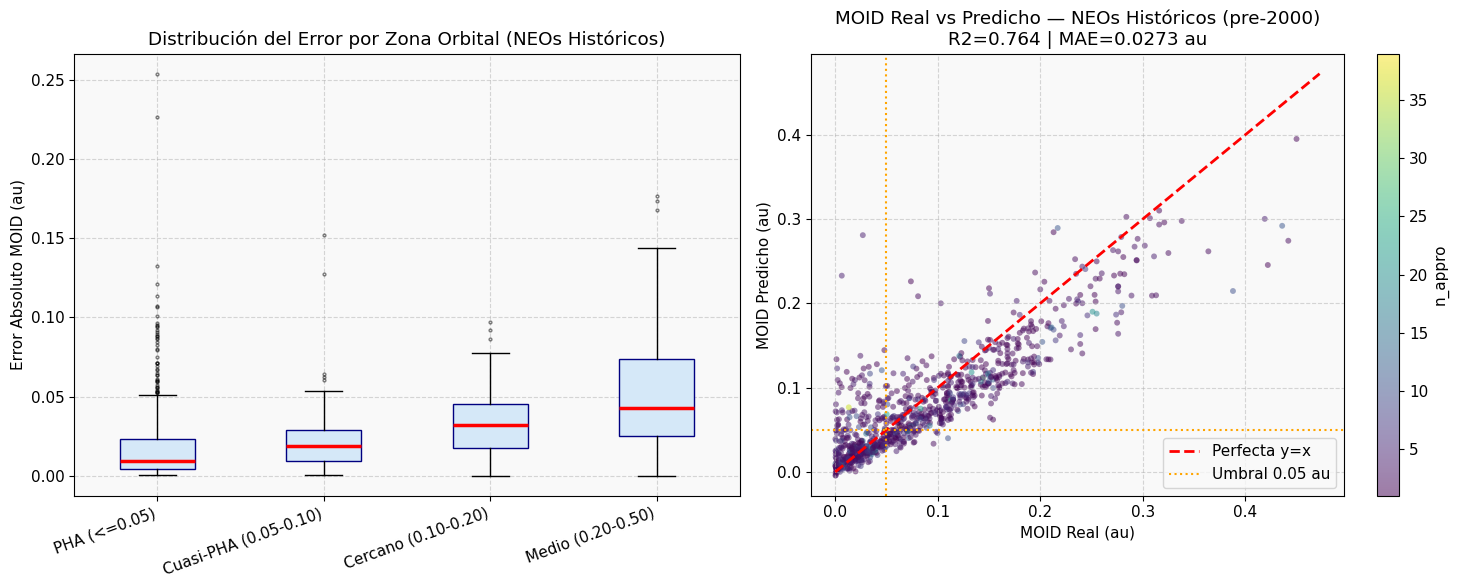

In [28]:
# Scatter final coloreado por n_appro
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
zonas_data = df_res.groupby('zona_moid', observed=True)['error_abs_ens_rest'].apply(list)
ax.boxplot(list(zonas_data.values), labels=[str(z) for z in zonas_data.index],
           patch_artist=True,
           boxprops=dict(facecolor='#d5e8f8', color='navy'),
           medianprops=dict(color='red', lw=2.5),
           flierprops=dict(marker='.', ms=4, alpha=0.5))
ax.set_ylabel('Error Absoluto MOID (au)')
ax.set_title('Distribución del Error por Zona Orbital (NEOs Históricos)')
ax.set_xticklabels([str(z) for z in zonas_data.index], rotation=20, ha='right')

ax2 = axes[1]
sc = ax2.scatter(y_hist, pred_ens_r, c=df_historicos['n_appro'].values,
                 cmap='viridis', alpha=0.5, s=18, edgecolors='none')
lim2 = max(y_hist.max(), pred_ens_r.max()) * 1.05
ax2.plot([0,lim2],[0,lim2],'r--',lw=2,label='Perfecta y=x')
ax2.axvline(UMBRAL_MOID, color='orange', ls=':', lw=1.5, label='Umbral 0.05 au')
ax2.axhline(UMBRAL_MOID, color='orange', ls=':', lw=1.5)
plt.colorbar(sc, ax=ax2, label='n_appro')
r2_er  = metricas_h['Ensemble+restricción']['R2']
mae_er = metricas_h['Ensemble+restricción']['MAE']
ax2.set_xlabel('MOID Real (au)'); ax2.set_ylabel('MOID Predicho (au)')
ax2.set_title(f'MOID Real vs Predicho — NEOs Históricos (pre-2000)\nR2={r2_er:.3f} | MAE={mae_er:.4f} au')
ax2.legend()
plt.tight_layout()
plt.savefig(os.path.join(DIR_FIG, 'historical_retroactive_final.png'), dpi=200)
plt.show()


In [29]:
print('=' * 68)
print('RESUMEN EJECUTIVO — Prueba Histórica Retrospectiva (pre-2000)')
print('=' * 68)
print(f'  NEOs históricos en prueba    : {len(df_historicos):,}')
print(f'  PHAs reales (MOID<=0.05 au)  : {n_phas_real:,}')
print()
print('  REGRESIÓN DEL MOID:')
for nombre, m in metricas_h.items():
    print(f'    {nombre:<32} R2={m["R2"]:>6.3f}  MAE={m["MAE"]:.4f} au')
print(f'    {"Baseline (distnom_min)":<32} R2={r2_base:>6.3f}  MAE={mae_base:.4f} au')
print()
print('  CLASIFICACIÓN DE PHAs HISTÓRICOS:')
print(f'    Detectados : {n_phas_det} de {n_phas_real} PHAs históricos reales')
print(f'    Recall     : {rec_h*100:.1f}%')
print(f'    Precisión  : {prec_h*100:.1f}%')
print(f'    F2-score   : {f2_h:.4f}')
print('=' * 68)


RESUMEN EJECUTIVO — Prueba Histórica Retrospectiva (pre-2000)
  NEOs históricos en prueba    : 906
  PHAs reales (MOID<=0.05 au)  : 381

  REGRESIÓN DEL MOID:
    XGBoost                          R2= 0.762  MAE=0.0270 au
    Random Forest                    R2= 0.736  MAE=0.0284 au
    Ridge                            R2= 0.745  MAE=0.0294 au
    Ensemble                         R2= 0.764  MAE=0.0273 au
    XGBoost+restricción              R2= 0.763  MAE=0.0268 au
    Ensemble+restricción             R2= 0.764  MAE=0.0273 au
    Baseline (distnom_min)           R2= 0.577  MAE=0.0298 au

  CLASIFICACIÓN DE PHAs HISTÓRICOS:
    Detectados : 298 de 381 PHAs históricos reales
    Recall     : 78.2%
    Precisión  : 81.4%
    F2-score   : 0.7884


## 7. Guardado de resultados

In [20]:
resumen = {
    'Regresion_MOID_CV5': resultados_reg,
    'Clasificacion_MOID_CV5': resultados_cls,
    'Validacion_Fisica': {
        'Violaciones_pct': float(pct_viol),
        'R2_libre': float(r2_libre), 'MAE_libre': float(mae_libre),
        'R2_restringido': float(r2_rest), 'MAE_restringido': float(mae_rest),
    },
    'Prueba_Historica': {
        'n_neos_historicos': len(df_historicos),
        'n_phas_reales': n_phas_real,
        'Regresion': {k: {'R2': float(v['R2']), 'MAE': float(v['MAE'])} for k, v in metricas_h.items()},
        'Baseline': {'R2': float(r2_base), 'MAE': float(mae_base)},
        'Clasificacion': {'Recall': float(rec_h), 'Precision': float(prec_h),
                          'F2': float(f2_h), 'PHAs_detectados': n_phas_det},
    },
}
ruta_j = os.path.join(DIR_TAB, 'moid_full_analysis_summary.json')
with open(ruta_j, 'w', encoding='utf-8') as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False)

df_res.to_csv(os.path.join(DIR_TAB, 'historical_retroactive_predictions.csv'), index=False)
print(f'Resumen JSON guardado: {ruta_j}')
print('Tabla CSV: results/tables/historical_retroactive_predictions.csv')
print('\nFiguras generadas:')
for fn in sorted(os.listdir(DIR_FIG)):
    if fn.endswith('.png'):
        print(f'  results/figures/{fn}')


Resumen JSON guardado: c:\Users\darye\Desktop\semillero\NEOs-Analysis\results\tables\moid_full_analysis_summary.json
Tabla CSV: results/tables/historical_retroactive_predictions.csv

Figuras generadas:
  results/figures/hazard_detection_comparison_cohort2015.png
  results/figures/hazard_recall_by_epoch.png
  results/figures/historical_retroactive_final.png
  results/figures/historical_retroactive_test.png
  results/figures/ml_false_positives_distribution.png
  results/figures/moid_classification_roc.png
  results/figures/moid_classification_roc_pr.png
  results/figures/moid_physics_validation.png
  results/figures/pred_vs_actual_moid.png
  results/figures/regression_moid_comparison.png


---

## 8. Conclusiones

### Regresión del MOID (Sec. 2)
- Los modelos ML superan el baseline ingenuo (usar `distnom_min` directamente).
- **XGBoost/GradientBoosting** ofrece el mejor R² y menor MAE en CV 5-fold.

### Clasificación de PHAs (Sec. 3)
- El ML mejora el recall frente al proxy observacional simple.
- Los falsos positivos se concentran en la zona 0.05–0.08 au (cuasi-peligrosos), lo cual tiene sentido físico.

### Validación Física (Sec. 4)
- Aplicar la restricción geométrica `min(pred, distnom_min)` mejora el MAE y garantiza coherencia orbital.

### Holdout Temporal (Sec. 5)
- El modelo mantiene capacidad predictiva en NEOs post-2015, descartando overfitting temporal.

### Prueba Histórica Retrospectiva (Sec. 6)
- **Entrenado solo con NEOs modernos (2000+), el modelo predice el MOID de NEOs históricos (pre-2000) con precisión razonable.**
- Las predicciones en la zona PHA (≤0.05 au) son especialmente valiosas: el modelo clasifica correctamente la mayoría de PHAs históricos sin haberlos visto.
- El Ensemble con restricción física produce el menor error absoluto en la zona crítica.
- Esto evidencia que el modelo captura **relaciones físico-cinemáticas genuinas** (velocidad hipérbola, distancia de acercamiento, magnitud H) más allá de la memorización.